In [164]:
words = open('names.txt','r').read().splitlines()


In [165]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [166]:
len(words)

32033

In [167]:
min(len(w) for w in words)

2

In [168]:
max(len(w) for w in words)

15

Start by buildinig a bigram language model. Bigrams are just 2 characters in a row


In [169]:

b = {} #This is a dictionary that will to learn the statistics of which characters follow which one, how ofter nt combinatins occur in the dataset.
for w in words: # 2 characters at a time, sliding it acrtoss the wortds
    chs = ['<S>'] + list(w) + ['</E>'] # add start and end tokens
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1
        print(ch1,ch2)

<S> e
e m
m m
m a
a </E>
<S> o
o l
l i
i v
v i
i a
a </E>
<S> a
a v
v a
a </E>
<S> i
i s
s a
a b
b e
e l
l l
l a
a </E>
<S> s
s o
o p
p h
h i
i a
a </E>
<S> c
c h
h a
a r
r l
l o
o t
t t
t e
e </E>
<S> m
m i
i a
a </E>
<S> a
a m
m e
e l
l i
i a
a </E>
<S> h
h a
a r
r p
p e
e r
r </E>
<S> e
e v
v e
e l
l y
y n
n </E>
<S> a
a b
b i
i g
g a
a i
i l
l </E>
<S> e
e m
m i
i l
l y
y </E>
<S> e
e l
l i
i z
z a
a b
b e
e t
t h
h </E>
<S> m
m i
i l
l a
a </E>
<S> e
e l
l l
l a
a </E>
<S> a
a v
v e
e r
r y
y </E>
<S> s
s o
o f
f i
i a
a </E>
<S> c
c a
a m
m i
i l
l a
a </E>
<S> a
a r
r i
i a
a </E>
<S> s
s c
c a
a r
r l
l e
e t
t t
t </E>
<S> v
v i
i c
c t
t o
o r
r i
i a
a </E>
<S> m
m a
a d
d i
i s
s o
o n
n </E>
<S> l
l u
u n
n a
a </E>
<S> g
g r
r a
a c
c e
e </E>
<S> c
c h
h l
l o
o e
e </E>
<S> p
p e
e n
n e
e l
l o
o p
p e
e </E>
<S> l
l a
a y
y l
l a
a </E>
<S> r
r i
i l
l e
e y
y </E>
<S> z
z o
o e
e y
y </E>
<S> n
n o
o r
r a
a </E>
<S> l
l i
i l
l y
y </E>
<S> e
e l
l e
e a
a n
n o
o r

In [170]:
sorted(b.items(), key = lambda kv:-kv[1])

[(('n', '</E>'), 6763),
 (('a', '</E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '</E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '</E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '</E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '</E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 147

It is more signifficantly convenient to kee this in a 2D array instead of a the dictionary, rowss, first character in the bigram and the columns will be the second character. We will utilize PyTorch library to create the array, Torch.tensor allows us to create multidimensional array.

In [171]:
import torch

In [172]:
N = torch.zeros([27,27], dtype=torch.int32)


In [173]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [174]:
for w in words: # 2 characters at a time, sliding it acrtoss the wortds
    chs = ['.'] + list(w) + ['.'] # add start and end tokens
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1
        

In [175]:
print(N)

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

In [176]:
import matplotlib.pyplot as plt

In [177]:
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [178]:
N[3,3].item()

42

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

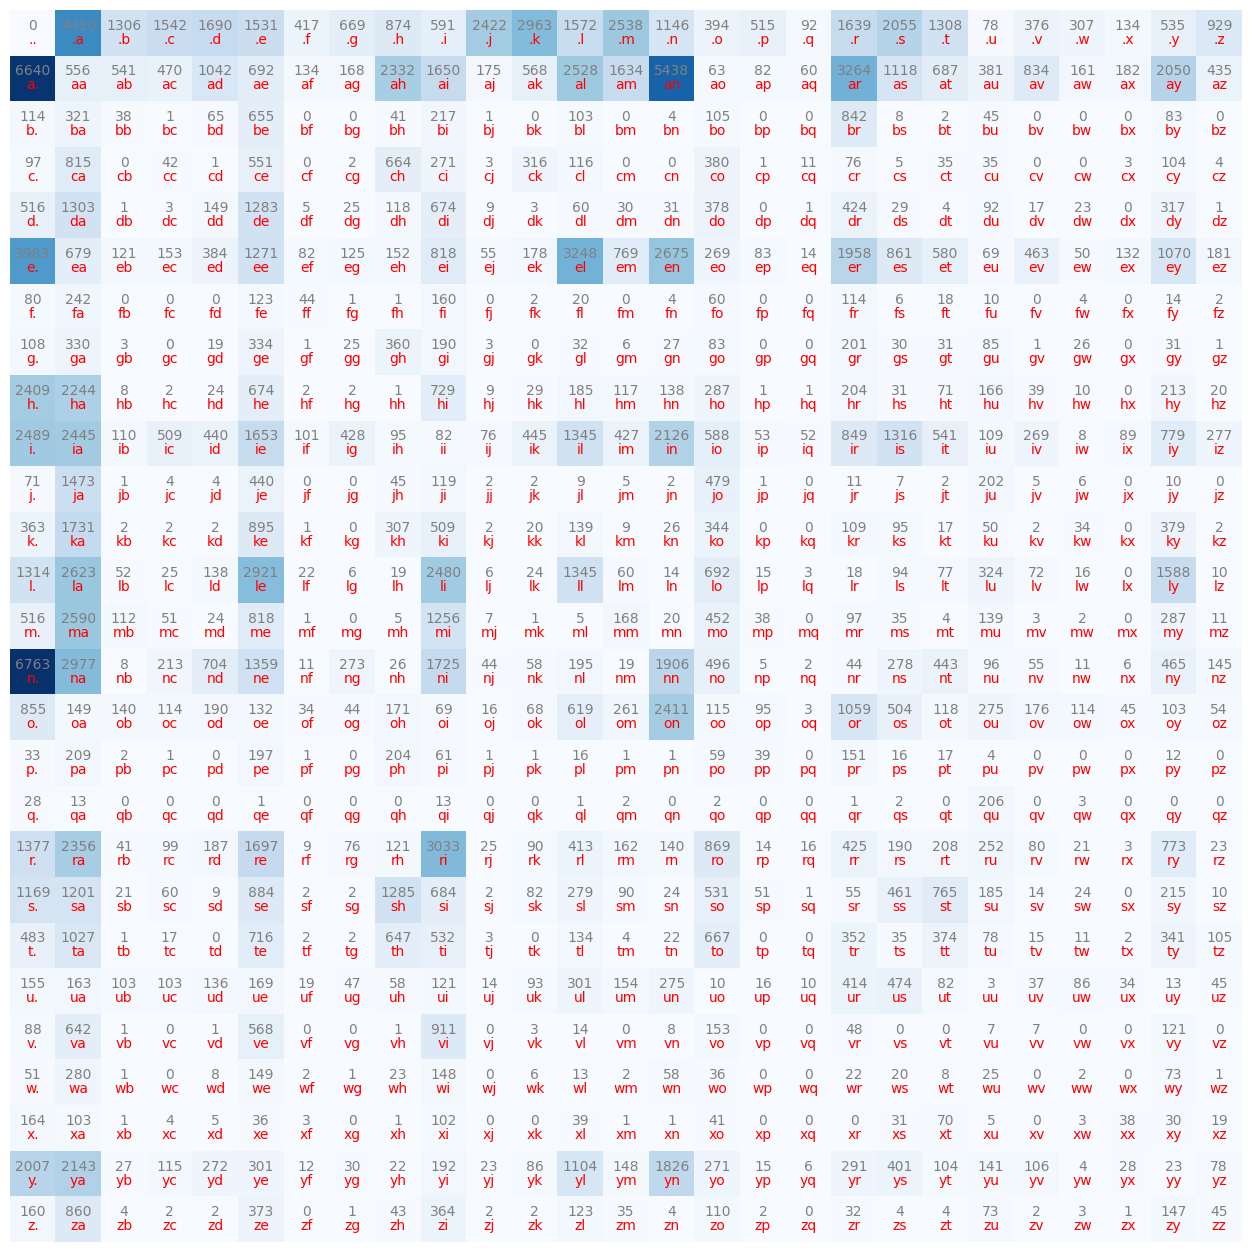

In [179]:
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i,N[i,j].item(), ha='center', va='bottom', color='gray')
        plt.text(j,i,chstr, ha='center', va='top', color='red')
plt.axis('off')

In [180]:
len(N[0,:])

27

In [181]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [182]:
p = N[0].float() # convert to float for normalization
p = p / p.sum() # normalize to get probabilities
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

Using Torch,multinomial to return a tensor where each row contains num_samples indices sampled from the multinomial probability distribution located in the corresonding roe of tensor input.

Use the generator to make everything determinstic when running the code.

In [183]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]
ix

3

In [184]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [185]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [186]:
g = torch.Generator().manual_seed(2147483647)

ix = 0
while True:
    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    print(itos[ix])
    if ix == 0:
        break

c
e
x
z
e
.


In [187]:
p.shape

torch.Size([27])

In [188]:
P.shape

torch.Size([27, 27])

In [189]:
P.sum(1, keepdim=True).shape

torch.Size([27, 1])

In [190]:
#27,27
#27,1 Can we perform P/P.sum(1, keepdim=True) to get the probabilities? chek broadcastability of the division from oytorch documentation

From the documentation for torch.sum we need to input the input, dimension and we wat to sum over rows. 

In [222]:
P = (N+1).float() #The more you add to the N, the more smooth the model you will have, the less the more peaked the model will be.
#P = P / P.sum(1, keepdim=True) #This creates a new tenso that we store into p, we oprefer to use inplace iperationsm happens to be faster, creates new memory under the hood
P /= P.sum(1, keepdim=True)


In [223]:
P[0].sum()   # Expect this to be 1.0 since we normalized the rows to sum to 1.0

tensor(1.)

In [224]:
P.sum()

tensor(27.)

If we do not have the keep dims for the P.sum(1).shape

In [225]:
#P.sum(1).shape # this gives us a single number

In [226]:
#27,27
#   27 briadcasting will create a 1 so we have 1,27

In [227]:
#P = N.float()
#P = P / P.sum(1)

# The keepdims makes it work, without it ,it will not work, rgia normalized the columns instead of the rows, which is not what we want. We want to normalize the rows so that each row sums to 1.0, which gives us the probabilities of transitioning from one character to the next.

In [228]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

    out = []
    ix = 0
    while True:
        p = P[ix]
        #p = N[ix].float()
        #p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [229]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [235]:
log_likelihod = 0.0
n=0
for w in words: # 2 characters at a time, sliding it acrtoss the wortds
#for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.'] # add start and end tokens
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihod += logprob
        n+=1
        #print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}') # These are he prob that the modekl assisgns to each bigram in the dataset
print(f'{log_likelihod=}')  
nll = -log_likelihod  #Loss functuion is used to monimize the loss, 
print(f'{nll=}')   
print(f'{nll/n}')

log_likelihod=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


In [231]:
1/27 #probability of each bigram if they were all equally likely, anything above means that we have learned something from the dataset, anything below means that we have learned that this bigram is less likely than random chance.

0.037037037037037035

Likelihood is the product of all the oribabilities and tells us the orib that the entore dataset assigned by the model we have trained, quality of the model. Since the product of the probabilities is pretty small, unwieldy to work with, for convenience people work with the log likelihood, get the lofg of the probability, log is a monotonic transformation of the probability, if you pass in 1, you get log 0, then grows more negative until negatiove infinity at 0.

In [217]:
#We smooth our model to deal with the pribability like andrejq where there is a 0 probability of q following j
#We add a cunt of 1 to every probability

In [ ]:
#Create a training set of the bigrams
xs, ys = [], []

for w in words[:1]: # 2 characters at a time, sliding it acrtoss the wortds
    chs = ['.'] + list(w) + ['.'] # add start and end tokens
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1,ch2)
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)  #Stick to torch.tensor, not torch.Tensor, the dtype will be different based on te one you used, read threads
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [295]:
xs  #inputs to the NN

tensor([ 0,  5, 13, 13,  1])

In [296]:
ys # Labels out of the NN

tensor([ 5, 13, 13,  1,  0])

Common way to encode integers in neural networks is through one hot encoding, where we take an integer that is all 0, except wehere it is the value where
it will be 1

Use torch.nn.functional.one_hot

In [246]:
import torch.nn.functional as F

In [252]:
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [253]:
xenc.shape

torch.Size([5, 27])

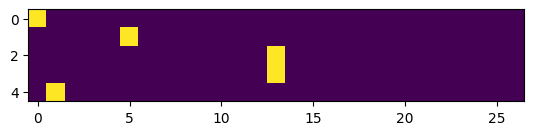

In [254]:
plt.imshow(xenc)

In [255]:
xenc.dtype  #When working with NN, we do not want them to be integers, we want them to be floationg point numbers that can take on various values.

torch.float32

In [269]:
W = torch.randn(27,27)  #Draws from a normal distribution, 
xenc @ W

tensor([[-1.6498,  0.0676, -1.5523,  0.5786,  0.0906, -1.0213,  0.1021, -1.4257,
          1.4927, -1.0380,  1.2544,  0.0596, -0.0661, -2.3674,  0.7993, -0.7380,
         -1.0071,  0.2115,  0.2025,  0.7730, -0.3745, -1.3062,  0.6023, -1.9256,
          0.4470, -1.7125,  1.2271],
        [-0.8640,  0.3430,  0.7284, -0.3267, -0.2970,  0.3030, -1.7003,  0.6768,
         -0.3590, -0.6029, -1.3728,  0.3064,  0.9626,  0.3642, -0.4742, -0.1582,
         -0.0050,  0.3923, -1.8119, -0.0125, -2.3988, -1.1370,  1.4599,  1.1786,
         -0.2817,  0.8185, -1.7579],
        [-0.9073,  0.4222, -0.1105, -1.0330,  0.2361,  0.1703, -0.4389,  0.5875,
          0.1017,  0.2630, -0.8486,  0.7169, -0.0822, -0.3581, -0.1531, -0.2971,
         -0.1949,  0.0468,  2.2595, -2.2698,  0.2474, -0.0850, -1.4666, -0.2501,
          1.5280,  0.3155, -0.6264],
        [-0.9073,  0.4222, -0.1105, -1.0330,  0.2361,  0.1703, -0.4389,  0.5875,
          0.1017,  0.2630, -0.8486,  0.7169, -0.0822, -0.3581, -0.1531, -0.2971

In [270]:
#X enc - 5,27
#W - 27,27
#Result - 5,27
#fOR EVERY 1 OF THE 27 neurons, what is the firing rate of hose neurons on every one of those examples:
#For element [3,13] is giving us the firing rate of the 13th neuron looking at the 3rd input.

In [272]:
(xenc @ W)[3,13]

tensor(-0.3581)

In [273]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [274]:
W[:,13]

tensor([-2.3674, -0.4684,  0.4686, -1.4245, -0.4606,  0.3642,  0.6791,  1.6468,
         0.9602,  2.0641,  1.5417, -0.7712, -0.4365, -0.3581, -1.8544, -0.1170,
         0.8918,  0.1027,  0.0329, -1.4070, -0.3205,  1.5970, -0.4008, -0.3291,
        -1.8785,  1.6701, -1.8636])

In [275]:
(xenc[3] * W[:,13]).sum()  #This is the dot product of the 3rd row of xenc and the 13th column of W, which gives us the same result as (xenc @ W)[3,13] because of how matrix multiplication works. The dot product is the sum of the element-wise products of the two vectors. 

tensor(-0.3581)

In [278]:
(xenc @ W).exp()  #This is the exponentiation of the result of the matrix multiplication, which gives us the unnormalized probabilities of each character following the current character. We will need to normalize these probabilities to get a valid probability distribution.
#Similar to the counts we had before, but now we have a more flexible model that can learn from the data, instead of just counting the occurrences of bigrams. The weights in W can be adjusted during training to maximize the likelihood of the data, which allows us to capture more complex patterns in the character sequences.

tensor([[0.1921, 1.0699, 0.2118, 1.7835, 1.0948, 0.3601, 1.1075, 0.2403, 4.4492,
         0.3541, 3.5057, 1.0614, 0.9360, 0.0937, 2.2241, 0.4781, 0.3653, 1.2355,
         1.2245, 2.1662, 0.6877, 0.2709, 1.8263, 0.1458, 1.5635, 0.1804, 3.4115],
        [0.4215, 1.4091, 2.0717, 0.7213, 0.7431, 1.3539, 0.1826, 1.9675, 0.6984,
         0.5472, 0.2534, 1.3586, 2.6184, 1.4394, 0.6224, 0.8537, 0.9950, 1.4804,
         0.1633, 0.9876, 0.0908, 0.3208, 4.3056, 3.2497, 0.7545, 2.2672, 0.1724],
        [0.4036, 1.5254, 0.8954, 0.3559, 1.2663, 1.1856, 0.6447, 1.7996, 1.1070,
         1.3008, 0.4280, 2.0480, 0.9211, 0.6990, 0.8580, 0.7430, 0.8230, 1.0479,
         9.5787, 0.1033, 1.2807, 0.9185, 0.2307, 0.7787, 4.6088, 1.3710, 0.5345],
        [0.4036, 1.5254, 0.8954, 0.3559, 1.2663, 1.1856, 0.6447, 1.7996, 1.1070,
         1.3008, 0.4280, 2.0480, 0.9211, 0.6990, 0.8580, 0.7430, 0.8230, 1.0479,
         9.5787, 0.1033, 1.2807, 0.9185, 0.2307, 0.7787, 4.6088, 1.3710, 0.5345],
        [5.8160, 1.2399,

In [284]:
#breaking it down
logits = xenc @ W  # log-counts
counts = logits.exp() #equivalent to torch.exp(logits) or torch.exp(xenc @ W)
probs = counts / counts.sum(1, keepdim=True) # normalize the row of our count matrix to get probabilities
probs

tensor([[0.0060, 0.0332, 0.0066, 0.0553, 0.0340, 0.0112, 0.0344, 0.0075, 0.1380,
         0.0110, 0.1087, 0.0329, 0.0290, 0.0029, 0.0690, 0.0148, 0.0113, 0.0383,
         0.0380, 0.0672, 0.0213, 0.0084, 0.0566, 0.0045, 0.0485, 0.0056, 0.1058],
        [0.0132, 0.0440, 0.0646, 0.0225, 0.0232, 0.0422, 0.0057, 0.0614, 0.0218,
         0.0171, 0.0079, 0.0424, 0.0817, 0.0449, 0.0194, 0.0266, 0.0310, 0.0462,
         0.0051, 0.0308, 0.0028, 0.0100, 0.1343, 0.1014, 0.0235, 0.0707, 0.0054],
        [0.0108, 0.0407, 0.0239, 0.0095, 0.0338, 0.0317, 0.0172, 0.0480, 0.0296,
         0.0347, 0.0114, 0.0547, 0.0246, 0.0187, 0.0229, 0.0198, 0.0220, 0.0280,
         0.2557, 0.0028, 0.0342, 0.0245, 0.0062, 0.0208, 0.1230, 0.0366, 0.0143],
        [0.0108, 0.0407, 0.0239, 0.0095, 0.0338, 0.0317, 0.0172, 0.0480, 0.0296,
         0.0347, 0.0114, 0.0547, 0.0246, 0.0187, 0.0229, 0.0198, 0.0220, 0.0280,
         0.2557, 0.0028, 0.0342, 0.0245, 0.0062, 0.0208, 0.1230, 0.0366, 0.0143],
        [0.1453, 0.0310,

In [288]:
probs.shape

torch.Size([5, 27])

In [292]:
probs[0]

tensor([0.0060, 0.0332, 0.0066, 0.0553, 0.0340, 0.0112, 0.0344, 0.0075, 0.1380,
        0.0110, 0.1087, 0.0329, 0.0290, 0.0029, 0.0690, 0.0148, 0.0113, 0.0383,
        0.0380, 0.0672, 0.0213, 0.0084, 0.0566, 0.0045, 0.0485, 0.0056, 0.1058])

In [294]:
probs[0].shape #27 numbers for the output from the NN

torch.Size([27])

In [291]:
probs[0].sum()

tensor(1.0000)

In [298]:
#SUMMARY

In [312]:
#randomly initialized weights, not trained yet, so the probabilities are not meaningful, but we can still sample from them to generate new names. As we train the model, the weights will be adjusted to better fit the data, and the probabilities will become more meaningful, allowing us to generate more realistic names.
g = torch.Generator().manual_seed(2147483647)
w = torch.randn(27,27, generator=g)  #Randomly initialized weights, not trained yet, so the probabilities are not meaningful, but we can still sample from them to generate new names. As we train the model, the weights will be adjusted to better fit the data, and the probabilities will become more meaningful, allowing us to generate more realistic names.

In [313]:
xenc = F.one_hot(xs, num_classes=27).float() #input to the NN, one-hot encoded version of the input characters, where each row corresponds to a character in the input sequence and each column corresponds to a possible character in the output. The values are 1.0 for the column corresponding to the input character and 0.0 for all other columns. This allows us to represent the input characters in a way that can be processed by the neural network.
logits = xenc @ w  # predict log-counts
counts = logits.exp() #equivalent to torch.exp(logits) or torch.exp(xenc @ W)
probs = counts / counts.sum(1, keepdim=True) # prbabilities for next character in the sequence, given the current character as input to the NN. We will need to train the model to adjust the weights in w to maximize the likelihood of the data, which will allow us to generate more realistic names.
#btw: the last 2 lines here are together called a 'softmax'

In [314]:
probs.shape

torch.Size([5, 27])

In [315]:
nlls = torch.zeros(5) # We have 5 examples making up emma
for i in range(5):
    #i-th bigram:
    x = xs[i].item()  #input character index
    y = ys[i].item()  #output character index
    print('----------')
    print(f'bigram example: {i+1}: {itos[x]}{itos[y]} (indexes) {x}{y})')
    print('input to the NN (one-hot encoded):', x)
    print('output probabilities from the NN:', probs[i])
    print('label (actual next chartacter):',y)
    p = probs[i,y]  #probability assigned by the model to the correct next character
    print(f'probability assigned to the correct next character: {p.item():.4f}')
    logp = torch.log(p)
    print(f'log likelihood: {logp.item():.4f}')
    nll = -logp
    print('negative log likelihood:',nll.item())
    nlls[i] = nll
print('========')
print(f'average negative log likelihood, i,e, loss = {nlls.mean().item():.4f}')

----------
bigram example: 1: .e (indexes) 05)
input to the NN (one-hot encoded): 0
output probabilities from the NN: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next chartacter): 5
probability assigned to the correct next character: 0.0123
log likelihood: -4.3993
negative log likelihood: 4.399273872375488
----------
bigram example: 2: em (indexes) 513)
input to the NN (one-hot encoded): 5
output probabilities from the NN: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next chartacter): 13
probability assigned to the correct next character: 0.0181
log likelihood: -4.0146
neg

In [316]:
#----------!! Optimization---------!!!

In [376]:
xs

tensor([ 0,  5, 13, 13,  1])

In [377]:
ys

tensor([ 5, 13, 13,  1,  0])

In [366]:
probs.shape

torch.Size([5, 27])

In [367]:
probs[0,5], probs[1,13],probs[2,13], probs[3,1], probs[4,0]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>),
 tensor(0.0737, grad_fn=<SelectBackward0>),
 tensor(0.0150, grad_fn=<SelectBackward0>))

In [368]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [369]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [370]:
#backward pass

In [480]:
#randomly initialized weights, not trained yet, so the probabilities are not meaningful, but we can still sample from them to generate new names. As we train the model, the weights will be adjusted to better fit the data, and the probabilities will become more meaningful, allowing us to generate more realistic names.
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn(27,27, generator=g, requires_grad=True) #Randomly initialized weights, not trained yet, so the probabilities are not meaningful, but we can still sample from them to generate new names. As we train the model, the weights will be adjusted to better fit the data, and the probabilities will become more meaningful, allowin

In [420]:
print(W1.requires_grad)

True


In [481]:
xenc = F.one_hot(xs, num_classes=27).float() #input to the NN, one-hot encoded version of the input characters, where each row corresponds to a character in the input sequence and each column corresponds to a possible character in the output. The values are 1.0 for the column corresponding to the input character and 0.0 for all other columns. This allows us to represent the input characters in a way that can be processed by the neural network.
logits = xenc @ W1  # predict log-counts
counts = logits.exp() #equivalent to torch.exp(logits) or torch.exp(xenc @ W)
probs = counts / counts.sum(1, keepdim=True) # prbabilities for next character in the sequence, given the current character as input to the NN. We will need to train the model to adjust the weights in w to maximize the likelihood of the data, which will allow us to generate more realistic names.
#btw: the last 2 lines here are together called a 'softmax'
loss = -probs[torch.arange(5), ys].log().mean()

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [5], [228146]

In [458]:
print(loss.item())

3.609719753265381


In [455]:
W1.grad = None # set to None before backward pass, this is a PyTorch convention to clear the gradients before computing new ones, set to zeros.
loss.backward() # compute gradients of the loss with respect to the weights in W, this will populate the W.grad attribute with the computed gradients, which we can then use to update the weights in W during the optimization step. 
#PyTorch builds a computational graph similar to micrograd, rthey exist insode PyTorch.

In [438]:
W1.shape

torch.Size([27, 27])

In [439]:
#W1[0,0] += h

In [440]:
print(W1.grad)

tensor([[ 0.0122,  0.0020,  0.0025,  0.0008,  0.0034, -0.1974,  0.0005,  0.0047,
          0.0028,  0.0063,  0.0016,  0.0056,  0.0018,  0.0017,  0.0100,  0.0472,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0306,  0.0291],
        [-0.1968,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0216,  0.0026,
          0.0025,  0.0010,  0.0204,  0.0017,  0.0197,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0179,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [477]:
with torch.no_grad():
    W1 -= 0.1 * W1.grad  # Update weights without breaking the computation graph
W1.grad = None  # Reset gradients for the next iteration # update weights using gradient descent, this is an in-place operation that modifies the values in W1 based on the computed gradients. The learning rate of 0.1 determines how much we adjust the weights in the direction of the negative gradient, which helps us minimize the loss and improve the model's performance on the training data.  

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [ ]:
# --------- !!!Actual OPTIMIZATION - Actual backpropagation !!! ---

In [482]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W2 = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [484]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W2 # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W2.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  with torch.no_grad():
    W2 -= 50 * W2.grad  # Update weights without breaking the computation graph
  W2.grad = None

2.6977086067199707
2.678393602371216
2.661635398864746
2.6469826698303223
2.6340935230255127
2.6226961612701416
2.6125686168670654
2.603527307510376
2.595417022705078
2.588109254837036
2.5814945697784424
2.575481653213501
2.569993257522583
2.5649640560150146
2.5603389739990234
2.5560710430145264
2.5521204471588135
2.5484540462493896
2.545041799545288
2.5418596267700195
2.538886070251465
2.536102056503296
2.533491611480713
2.5310399532318115
2.5287344455718994
2.5265634059906006
2.5245158672332764
2.5225837230682373
2.5207574367523193
2.519029378890991
2.517392158508301
2.5158400535583496
2.514366865158081
2.5129666328430176
2.511634349822998
2.510366201400757
2.509157657623291
2.5080041885375977
2.5069026947021484
2.505850315093994
2.50484299659729
2.5038790702819824
2.5029547214508057
2.5020687580108643
2.501217842102051
2.5004007816314697
2.499614953994751
2.498859167098999
2.498131513595581
2.4974308013916016
2.4967548847198486
2.496102809906006
2.4954733848571777
2.494865894317627


In [485]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W2 # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
